# Simulation of TESLA cavity dynamics

The idea is to generate data that describes our prior knowledge about the detuning of a TESLA cavity system.

In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries and KIND framework files --!

import torch
import numpy as np

from matplotlib import pyplot as plt

import utils_data
import utils_detuning

### Data acquisition through simulation

inf >> half-bandwidth of this radio frequency cavity is 14.44 Herz
inf >> cavity filling time is 0.07 seconds
inf >> number of mechanical modes specified: 1
inf >> number of mechanical modes specified: 1
inf >> number of mechanical modes specified: 1
inf >> number of mechanical modes specified: 1
inf >> number of mechanical modes specified: 2
inf >> number of mechanical modes specified: 2
inf >> number of mechanical modes specified: 2
inf >> number of mechanical modes specified: 2
inf >> number of mechanical modes specified: 2
inf >> number of mechanical modes specified: 2
inf >> number of mechanical modes specified: 3
inf >> number of mechanical modes specified: 3
inf >> number of mechanical modes specified: 3
inf >> number of mechanical modes specified: 3
inf >> number of mechanical modes specified: 4


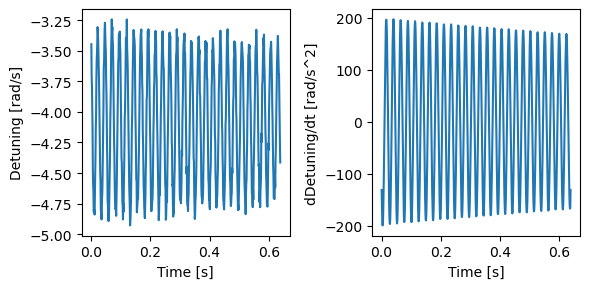

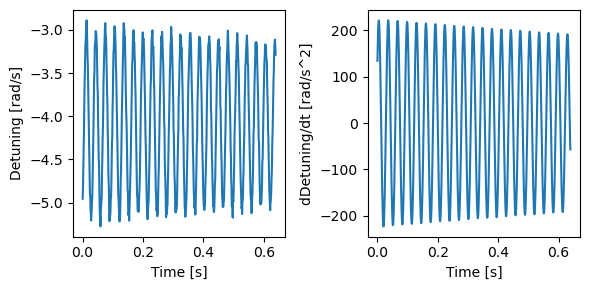

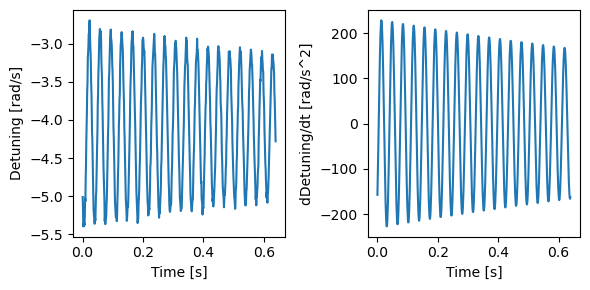

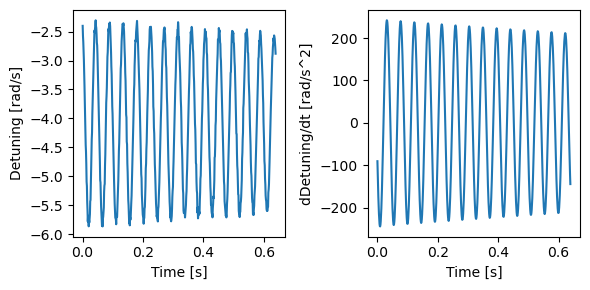

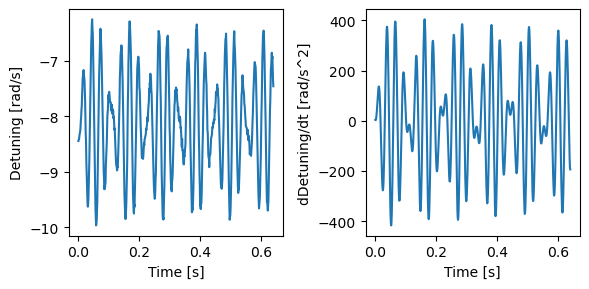

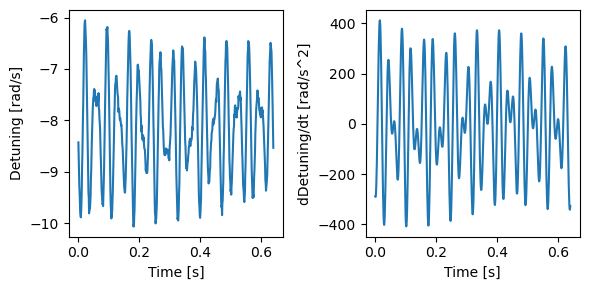

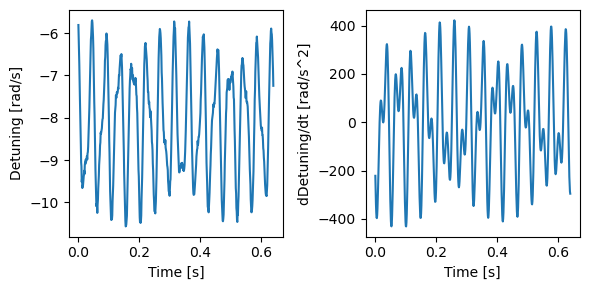

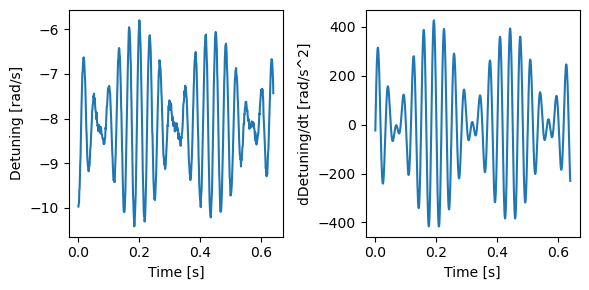

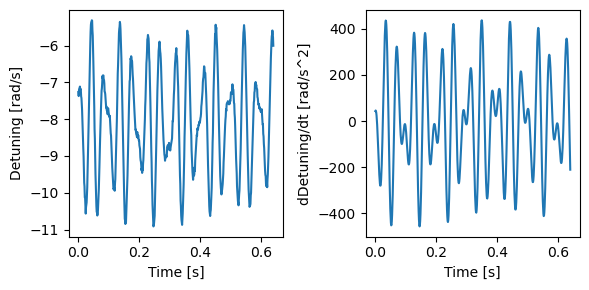

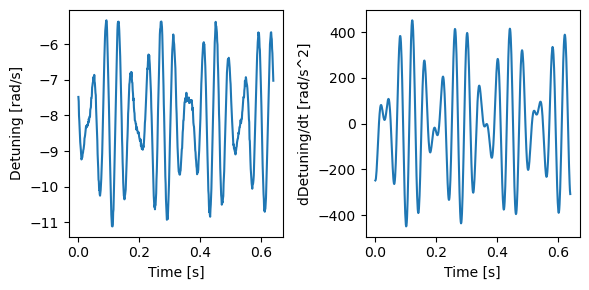

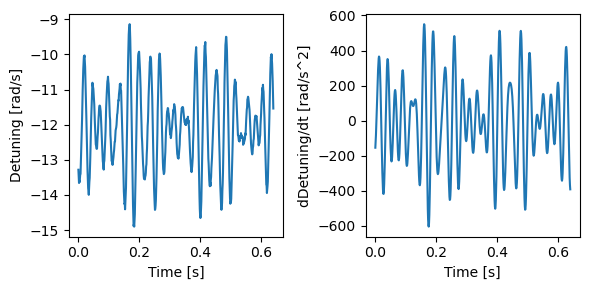

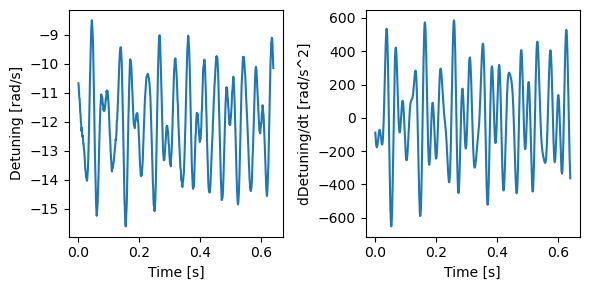

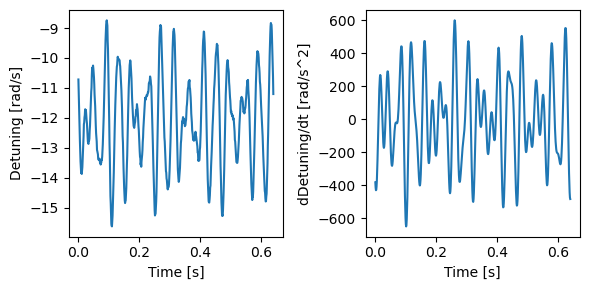

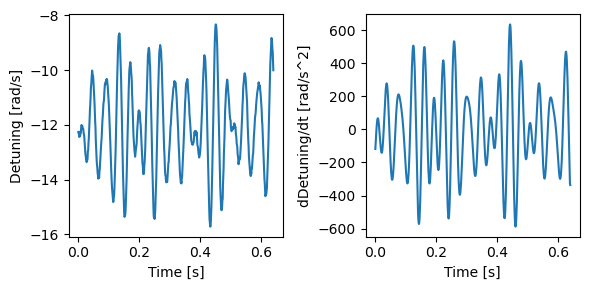

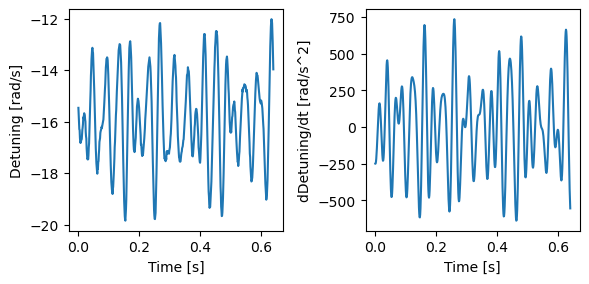

inf >> final detuning shape is (640, 1)


In [2]:
# --! simulate detuning using a cavity simulator --!

# --! instatiate a cavity simulator
config = {
    'q_rf'       : 4.5e7,      # loaded quality factor
    'f_rf'       : 1.3e9,      # cavity frequency in hertz
    'v_rf'       : [5., 0.],   # generator voltage I and Q
    'pctr_on_rf' : False,      # prortional controller is on
    'K_rf'       : 100.        # proportional controller gain
}
sim = utils_detuning.detuning_sim(config)

dt = 0.001 # discretization step
ns = 0.05 # rms noise level

# --! define a list of simulation parameters
sim_param = [
    {
        'f_m'    : np.array([41.]),
        'fe_m'   : np.array([0.]),
        'q_m'    : np.array([400.]),
        't_m'    : np.array([[-1., -1.]]),
        't_rf_n' : 10,
        'dt'     : dt,
    },
    {
        'f_m'    : np.array([32.]),
        'fe_m'   : np.array([0.]),
        'q_m'    : np.array([320.]),
        't_m'    : np.array([[-1., -1.]]),
        't_rf_n' : 10,
        'dt'     : dt,
    },
    {
        'f_m'    : np.array([28.]),
        'fe_m'   : np.array([0.]),
        'q_m'    : np.array([150.]),
        't_m'    : np.array([[-1., -1.]]),
        't_rf_n' : 10,
        'dt'     : dt,
    },
    {
        'f_m'    : np.array([22.]),
        'fe_m'   : np.array([0.]),
        'q_m'    : np.array([220.]),
        't_m'    : np.array([[-1., -1.]]),
        't_rf_n' : 10,
        'dt'     : dt,
    },
    {
        'f_m'    : np.array([41., 32.]),
        'fe_m'   : np.array([0., 0.]),
        'q_m'    : np.array([400., 320.]),
        't_m'    : np.array([[-1., -1.], [-1., -1.]]),
        't_rf_n' : 10,
        'dt'     : dt,
    },
    {
        'f_m'    : np.array([41., 28.]),
        'fe_m'   : np.array([0., 0.]),
        'q_m'    : np.array([400., 150.]), 
        't_m'    : np.array([[-1., -1.], [-1., -1.]]),
        't_rf_n' : 10,
        'dt'     : dt,
    },
    {
        'f_m'    : np.array([41., 22.]),
        'fe_m'   : np.array([0., 0.]),
        'q_m'    : np.array([400., 220.]),
        't_m'    : np.array([[-1., -1.], [-1., -1.]]),
        't_rf_n' : 10,
        'dt'     : dt,
    },
    {
        'f_m'    : np.array([32., 28.]),
        'fe_m'   : np.array([0., 0.]),
        'q_m'    : np.array([320., 150.]), 
        't_m'    : np.array([[-1., -1.], [-1., -1.]]),
        't_rf_n' : 10,
        'dt'     : dt,
    },
    {
        'f_m'    : np.array([32., 22.]),
        'fe_m'   : np.array([0., 0.]),
        'q_m'    : np.array([320., 220.]), 
        't_m'    : np.array([[-1., -1.], [-1., -1.]]),
        't_rf_n' : 10,
        'dt'     : dt,
    },
    {
        'f_m'    : np.array([28., 22.]),
        'fe_m'   : np.array([0., 0.]),
        'q_m'    : np.array([150., 220.]), 
        't_m'    : np.array([[-1., -1.], [-1., -1.]]),
        't_rf_n' : 10,
        'dt'     : dt,
    },
    {
        'f_m'    : np.array([41., 32., 28.]),
        'fe_m'   : np.array([0., 0., 0.]),
        'q_m'    : np.array([400., 320., 150.]),
        't_m'    : np.array([[-1., -1.], [-1., -1.], [-1., -1.]]),
        't_rf_n' : 10,
        'dt'     : dt,
    },
    {
        'f_m'    : np.array([41., 32., 22.]),
        'fe_m'   : np.array([0., 0., 0.]),
        'q_m'    : np.array([400., 320., 220.]),
        't_m'    : np.array([[-1., -1.], [-1., -1.], [-1., -1.]]),
        't_rf_n' : 10,
        'dt'     : dt,
    },
    {
        'f_m'    : np.array([41., 28., 22.]),
        'fe_m'   : np.array([0., 0., 0.]),
        'q_m'    : np.array([400., 150., 220.]),
        't_m'    : np.array([[-1., -1.], [-1., -1.], [-1., -1.]]),
        't_rf_n' : 10,
        'dt'     : dt,
    },
    {
        'f_m'    : np.array([32., 28., 22.]),
        'fe_m'   : np.array([0., 0., 0.]),
        'q_m'    : np.array([320., 150., 220.]),
        't_m'    : np.array([[-1., -1.], [-1., -1.], [-1., -1.]]),
        't_rf_n' : 10,
        'dt'     : dt,
    },
    {
        'f_m'    : np.array([41., 32., 28., 22.]),
        'fe_m'   : np.array([0., 0., 0., 0.]),
        'q_m'    : np.array([400., 320., 150., 220.]),
        't_m'    : np.array([[-1., -1.], [-1., -1.], [-1., -1.], [-1., -1.]]),
        't_rf_n' : 10,
        'dt'     : dt,
    },
]

# --! simulate
detuning_sim_stat = sim(sim_param, start=60, noise=ns)

# --! display detuning results
for d in detuning_sim_stat:
    sim.disp(d, timestep=dt)

# --! but dump velocity state, as we do not need it now
for j in range(len(detuning_sim_stat)):
    detuning_sim_stat[j] = detuning_sim_stat[j][:, :1]
print(f'inf >> final detuning shape is {detuning_sim_stat[0].shape}')

detuning_sim_nsample = detuning_sim_stat[0].shape[0]

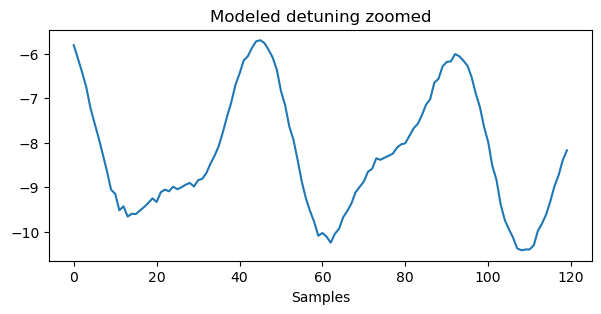

In [3]:
# --! inspect individual modeled detuning --!

plt.figure(figsize=(7, 3))
plt.title('Modeled detuning zoomed')
plt.plot(detuning_sim_stat[6][:120, 0])
plt.xlabel('Samples')
plt.show()

### Data saving for model development

In [4]:
# --! save the stationary dataset for training --!

datasaved = True

if datasaved:
    datadir      = '../../data/baselines/tesla_train_stat'
    data_nsample = 120
    utils_data.save_traindata(detuning_sim_stat, datadir, data_nsample)

inf >> training files saved
